In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectPercentile,chi2,f_classif
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings(action="ignore")

In [2]:
dff = pd.read_csv("processed_data.csv")


In [3]:
dff.columns

Index(['time', 'comp', 'round', 'day', 'result', 'gf', 'ga', 'opponent', 'xg',
       'xga', 'poss', 'attendance', 'captain', 'formation', 'referee',
       'match report', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season',
       'team', 'XGD', 'Weekend', '+/-', 'venue_Away', 'venue_Home',
       'team_encoded', 'day_encoded', 'opponent_encoded', 'result_encoded',
       'formation_encoded', 'venue_Away_encoded', 'venue_Home_encoded'],
      dtype='object')

In [4]:
dff=dff[[ 'gf', 'ga', 'xg', 'xga', 'poss', 'attendance',  'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'XGD', 'Weekend', '+/-', 'day_encoded',
       'team_encoded', 'opponent_encoded', 'result_encoded','formation_encoded','venue_Away_encoded', 'venue_Home_encoded']]

In [5]:
# Calculate the correlation of all columns in the DataFrame with the 'result_encoded' column

dff.corr()['result_encoded']

gf                    0.510626
ga                   -0.260415
xg                    0.318113
xga                  -0.211080
poss                  0.088210
attendance            0.031285
sh                    0.163811
sot                   0.305274
dist                 -0.093216
fk                    0.011603
pk                         NaN
pkatt                      NaN
season                0.018092
XGD                   0.329722
Weekend               0.000149
+/-                   0.509278
day_encoded           0.020680
team_encoded         -0.008972
opponent_encoded      0.034508
result_encoded        1.000000
formation_encoded     0.008719
venue_Away_encoded   -0.062110
venue_Home_encoded    0.062110
Name: result_encoded, dtype: float64

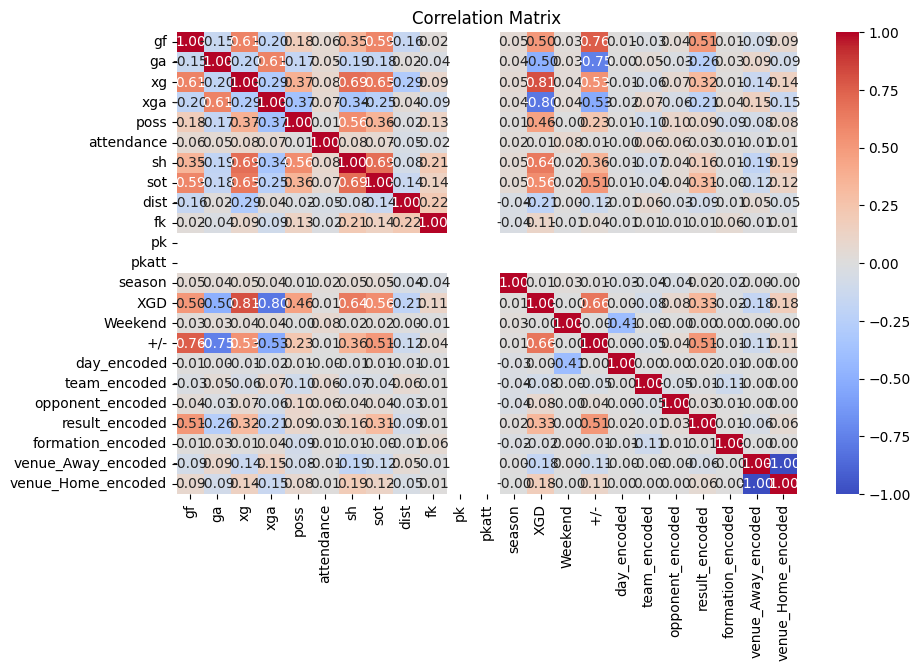

In [6]:
data=dff.corr()
plt.figure(figsize=(10,6))
sns.heatmap(data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Features Selection
### The code selects the top 80% of features from the dataset x based on their statistical relevance to the target variable y.

In [7]:
X=dff[[ 'gf', 'ga', 'xg', 'xga', 'poss', 'attendance',  'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt',  'XGD',  '+/-',
       'team_encoded', 'opponent_encoded','venue_Away_encoded', 'venue_Home_encoded']]
Y=dff['result_encoded']

In [8]:
from sklearn.feature_selection import SelectPercentile, f_classif
import pandas as pd

# Assuming X is the feature matrix and Y is the target vector
function_selection = SelectPercentile(score_func=f_classif, percentile=80)

# Apply feature selection
x_selection = function_selection.fit_transform(X, Y)

# Create a DataFrame with the selected features
pd.DataFrame(x_selection,columns=[i for i,j in zip(X,function_selection.get_support())if j])

# Display the selected features DataFrame


,gf,ga,xg,xga,poss,sh,sot,dist,fk,XGD,+/-,team_encoded,venue_Away_encoded,venue_Home_encoded
0,3.0,1.0,1.9,0.60,65.0,13.0,8.0,21.1,2.0,1.30,2.0,14.0,1.0,0.0
1,2.0,5.0,0.9,2.90,72.0,16.0,5.0,19.8,1.0,-2.00,-3.0,14.0,0.0,1.0
2,1.0,1.0,1.2,2.40,49.0,23.0,1.0,18.2,1.0,-1.20,0.0,14.0,1.0,0.0
3,1.0,0.0,1.3,0.90,58.0,13.0,5.0,17.7,0.0,0.40,1.0,14.0,0.0,1.0
4,1.0,1.0,1.0,0.30,69.0,14.0,7.0,20.9,1.0,0.70,0.0,14.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4781,1.0,2.0,1.2,1.20,56.0,12.0,3.0,16.9,1.0,0.00,-1.0,17.0,1.0,0.0
4782,0.0,4.0,0.6,3.45,53.0,11.0,2.0,19.8,1.0,-2.85,-4.0,17.0,0.0,1.0
4783,0.0,1.0,0.1,2.50,33.0,2.0,0.0,20.6,0.0,-2.40,-1.0,17.0,1.0,0.0
4784,0.0,2.0,0.3,1.80,42.0,6.0,2.0,13.4,0.0,-1.50,-2.0,17.0,0.0,1.0


In [9]:
x=dff[[ 'gf', 'ga', 'xg', 'xga', 'poss',  'sh', 'sot', 'dist', 'fk',  'XGD',  '+/-','team_encoded','venue_Away_encoded', 'venue_Home_encoded']]
y=dff['result_encoded']

## Train/Test dataset
### We split our dataset into train and test set:


In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=4)
print ('Train set:', x_train.shape,  y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (3350, 14) (3350,)
Test set: (1436, 14) (1436,)


# Build Classification Model using KNN Algorithm

In [11]:
knn = KNeighborsClassifier()
param_knn = {'n_neighbors': range(1, 21)}
grid_knn = GridSearchCV(knn, param_knn, cv=5)
grid_knn.fit(x_train, y_train)
print(f"Best Parameters: {grid_knn.best_params_}")

Best Parameters: {'n_neighbors': 1}


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Define the model
knn = KNeighborsClassifier()

# Define the parameter grid to test
param_grid = {
    'n_neighbors': [3, 5, 7, 9],               # Different values for k (number of neighbors)
    'weights': ['uniform', 'distance'],        # Weighting method for neighbors
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Search algorithms
    'leaf_size': [10, 20, 30, 40, 50],         # Leaf size for BallTree and KDTree
    'metric': ['minkowski', 'manhattan'],      # Distance metrics to use
    'p': [1, 2]                                # Power parameter for Minkowski distance (1: Manhattan, 2: Euclidean)
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=knn,       # The model we want to perform grid search on
    param_grid=param_grid,  # The grid of parameters to test
    scoring='accuracy',  # Metric to evaluate the performance (accuracy in this case)
    cv=5,                # Number of cross-validation folds
    verbose=2,           # Show information during execution
    n_jobs=-1            # Use all available processors
)

# Fit the grid search on the training data
grid_search.fit(x_train, y_train)

# Display the best parameters found during the grid search
print("Best Parameters:", grid_search.best_params_)

# Display the best score achieved during the grid search
print("Best Score:", grid_search.best_score_)


Fitting 5 folds for each of 640 candidates, totalling 3200 fits


Best Parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best Score: 0.8749253731343284


In [13]:
neigh = KNeighborsClassifier(
    algorithm='auto',
    leaf_size=20,
    metric='minkowski',
    n_neighbors=9,
    p=1,
    weights='distance'
)

In [14]:
neigh.fit(x_train,y_train)

KNeighborsClassifier(leaf_size=20, n_neighbors=9, p=1, weights='distance')

In [15]:
knn_predict= neigh.predict(x_test)
knn_predict

array([0, 1, 1, ..., 1, 0, 2], dtype=int64)

In [16]:
from sklearn import metrics
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(x_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, knn_predict))

Train set Accuracy:  1.0
Test set Accuracy:  0.887883008356546


In [17]:
class_knn=classification_report(y_test,knn_predict)
print(class_knn)

              precision    recall  f1-score   support

           0       0.80      0.71      0.75       330
           1       0.90      0.94      0.92       554
           2       0.92      0.95      0.93       552

    accuracy                           0.89      1436
   macro avg       0.87      0.86      0.87      1436
weighted avg       0.88      0.89      0.89      1436



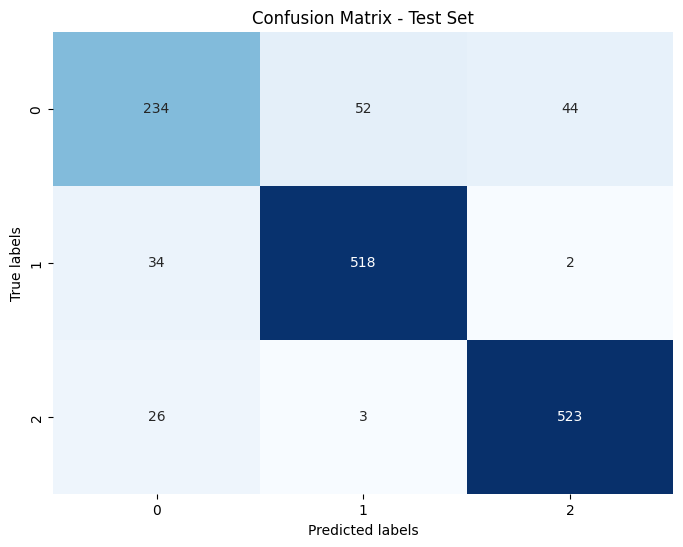

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for test set
conf_matrix_test = confusion_matrix(y_test, knn_predict)

# Plot confusion matrix for test set
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - Test Set')
plt.show()

# predict Unseen data


In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


data = {
    'result': ['Win', 'Draw', 'Loss', 'Win', 'Draw','Win',"Loss"],
    'gf': [2, 3, 1, 2, 4,5,1],
    'ga': [1, 2, 2, 1, 3,0,3],
    'xg': [1.8, 2.1, 1.5, 2.3, 2.0,6.0,1.0],
    'xga': [1.0, 1.5, 1.3, 1.2, 1.8,2.1,5.0],
    'poss': [55.5, 60.0, 50.0, 57.0, 53.5,55.0,45.0],
    'sh': [12, 15, 10, 14, 13,15,5],
    'sot': [5, 6, 4, 7, 5,4,10],
    'dist': [100, 110, 95, 105, 120,130,100],
    'fk': [3, 2, 4, 5, 3,5,1],
    'team': ['Team A', 'Team B', 'Team C', 'Team A', 'Team B',"Team C","Team D"],
    'XGD': [1.2, 0.5, -0.2, 0.8, 1.1,3.9,-4.0],
    '+/-': [2,0,-2,2,0,5,-2],
    'venue_Away': [0, 1, 0, 1, 0,0,1],
    'venue_Home': [1, 0, 1, 0, 1,1,0]
}

df = pd.DataFrame(data)
label_encoder = LabelEncoder()

df['team_encoded'] = label_encoder.fit_transform(df['team'])
df['venue_Away_encoded'] = label_encoder.fit_transform(df['venue_Away'])
df['venue_Home_encoded'] = label_encoder.fit_transform(df['venue_Home'])

final_test=df[[ 'gf', 'ga', 'xg', 'xga', 'poss',  'sh', 'sot', 'dist', 'fk',  'XGD',  '+/-','team_encoded','venue_Away_encoded', 'venue_Home_encoded']]

In [20]:
predictions = neigh.predict(final_test)

print("Predictions:", predictions)

Predictions: [2 1 0 2 2 2 1]
